# ỨNG DỤNG 3: PHÂN LOẠI HÀNH VI & KHUYẾN NGHỊ KHÁCH HÀNG (E-COMMERCE CUSTOMER BEHAVIOR & NLP)
**Học phần:** Phát triển Hệ thống Thông minh (Intelligent System Development)  
**Quy trình:** Data $\rightarrow$ Clean $\rightarrow$ Represent $\rightarrow$ Learn $\rightarrow$ Evaluate $\rightarrow$ Persist $\rightarrow$ Deploy  

## 1. Problem Definition (Định nghĩa bài toán)

### 1.1. Bối cảnh và mục tiêu kinh doanh
Trong thương mại điện tử (E-commerce), việc thấu hiểu phản hồi định tính của khách hàng từ các bài đánh giá (Reviews) đóng vai trò sống còn trong việc nâng cao chất lượng sản phẩm và giữ chân người tiêu dùng. Mục tiêu của hệ thống là **phân tích ngôn ngữ tự nhiên (NLP) từ tiêu đề và nội dung nhận xét để tự động dự đoán liệu khách hàng có khuyến nghị sản phẩm đó hay không (`Recommended IND`)**, đồng thời khám phá các cụm từ thể hiện sự hài lòng hoặc thất vọng.

### 1.2. Phát biểu hệ thống thông minh
- **Dữ liệu đầu vào ($X$):** Văn bản nhận xét của khách hàng gồm `Title` và `Review Text`.
- **Biểu diễn nội bộ:** Chuỗi biến đổi NLP: $\text{Text} \rightarrow \text{Tokens} \rightarrow \text{Token IDs} \rightarrow \text{TF-IDF Feature Vector} \in \mathbb{R}^{3500}$.
- **Đầu ra mục tiêu ($y$):** Biến nhãn nhị phân $y \in \{0, 1\}$ ($0$: Không khuyến nghị, $1$: Khuyến nghị mua).
- **Quyết định hệ thống:** Đánh giá mức độ hài lòng tự động và cảnh báo sớm nguy cơ khách hàng trả lại hàng (Return/Refund).

### 1.3. Mô hình hóa toán học
Đây là bài toán **Phân loại văn bản có giám sát (Supervised Text Classification)**.  
Hệ thống học hàm phân loại $f_\theta: \mathbb{R}^d \rightarrow \{0, 1\}$ với không gian từ vựng $d = 3500$ đặc trưng n-gram.

## 2. Dataset Source (Nguồn dữ liệu)

| Tiêu chí | Chi tiết thông tin |
|---|---|
| **Tên bộ dữ liệu** | Women's E-Commerce Clothing Reviews |
| **Nguồn phát hành** | Kaggle ([Women's E-Commerce Clothing Reviews](https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews)) |
| **Số lượng quan sát ban đầu** | 23,486 bài đánh giá thực tế của khách hàng |
| **Tệp dữ liệu cục bộ** | `Womens Clothing E-Commerce Reviews.csv` |

## 3. Dataset Loading (Nạp dữ liệu)

In [1]:
from pathlib import Path
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("Womens Clothing E-Commerce Reviews.csv") if Path("Womens Clothing E-Commerce Reviews.csv").exists() else Path("customer_behavior/Womens Clothing E-Commerce Reviews.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
df_raw = df.copy()

print(f" Đã nạp thành công: {DATA_PATH.name}")
print(f" Quy mô: {df.shape[0]:,} dòng đánh giá, {df.shape[1]} thuộc tính")

 Đã nạp thành công: Womens Clothing E-Commerce Reviews.csv
 Quy mô: 23,486 dòng đánh giá, 11 thuộc tính


## 4. Dataset Inspection (Khảo sát cấu trúc dữ liệu)

In [2]:
# Hiển thị các thuộc tính tiêu biểu
display(df.head(3))

# Thông tin cột và kiểu dữ liệu
df.info()

# Thống kê mô tả các biến số
display(df.describe().round(2))

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses


<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 2.0 MB


,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.00,23486.00,23486.00,23486.00,23486.00,23486.00
mean,11742.50,918.12,43.20,4.20,0.82,2.54
std,6779.97,203.30,12.28,1.11,0.38,5.70
min,0.00,0.00,18.00,1.00,0.00,0.00
25%,5871.25,861.00,34.00,4.00,1.00,0.00
50%,11742.50,936.00,41.00,5.00,1.00,1.00
75%,17613.75,1078.00,52.00,5.00,1.00,3.00
max,23485.00,1205.00,99.00,5.00,1.00,122.00


## 5. Data-Quality Analysis (Đánh giá chất lượng dữ liệu)

### Phân tích hiện tượng mất cân bằng lớp (Class Imbalance)

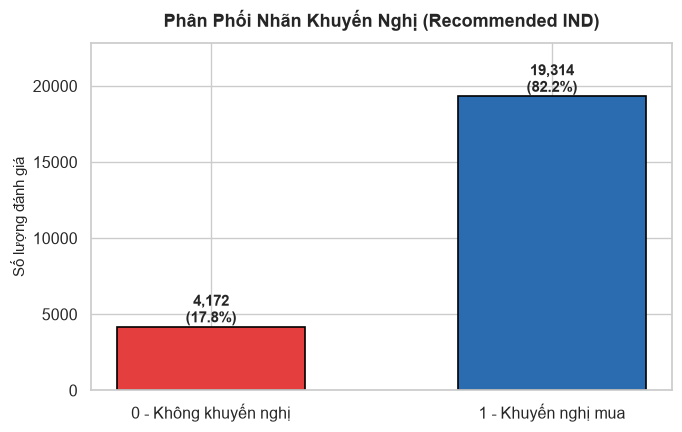

In [3]:
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE_ECOMMERCE = ["#E53E3E", "#2B6CB0"]  # Negative (Red) vs Positive (Blue)

TARGET = "Recommended IND"
target_counts = df[TARGET].value_counts().sort_index()
target_pct = df[TARGET].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7, 4.5))
bars = plt.bar(["0 - Không khuyến nghị", "1 - Khuyến nghị mua"], target_counts, color=PALETTE_ECOMMERCE, width=0.55, edgecolor="black", linewidth=1.2)
plt.title("Phân Phối Nhãn Khuyến Nghị (Recommended IND)", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("Số lượng đánh giá", fontsize=11)
plt.ylim(0, target_counts.max() * 1.18)

for bar, count, pct in zip(bars, target_counts, target_pct):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, f"{count:,}\n({pct:.1f}%)", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

**Nhận xét về chất lượng phân phối nhãn:**
- Lớp 1 chiếm đa số áp đảo với **82.2%** (19,314 bài), trong khi Lớp 0 chỉ chiếm **17.8%** (4,172 bài).
- Đây là bài toán mất cân bằng nhãn nặng ($4.6 : 1$). Nếu chỉ dùng độ chính xác thuần túy (Accuracy), một mô hình "ngây thơ" luôn đoán là 1 vẫn đạt 82.2% mà hoàn toàn vô dụng.
- **Giải pháp ML:** Bắt buộc áp dụng trọng số cân bằng lớp (`class_weight='balanced'`) trong mô hình học máy và ưu tiên đánh giá bằng **Macro/Weighted F1-score**, **Recall** và **ROC-AUC**.

## 6. Missing-Value Analysis (Phân tích giá trị khuyết thiếu)

In [4]:
missing_series = df.isnull().sum()
missing_pct = (missing_series / len(df)) * 100
missing_report = pd.DataFrame({"Số lượng thiếu": missing_series, "Tỷ lệ %": missing_pct.round(2)})
display(missing_report[missing_report["Số lượng thiếu"] > 0])

,Số lượng thiếu,Tỷ lệ %
Title,3810,16.22
Review Text,845,3.60
Division Name,14,0.06
Department Name,14,0.06
Class Name,14,0.06


## 7. Duplicate Analysis (Phân tích bản ghi trùng lặp)

In [5]:
dup_reviews = df.duplicated(subset=["Review Text"]).sum()
print(f"Số lượng review trùng lặp văn bản: {dup_reviews:,} bài")

Số lượng review trùng lặp văn bản: 851 bài


## 8. Invalid-Value Analysis (Phân tích giá trị không hợp lệ)

In [6]:
empty_reviews = df["Review Text"].dropna().apply(lambda x: len(str(x).strip()) == 0).sum()
print(f"Số lượng review chỉ chứa khoảng trắng: {empty_reviews}")

Số lượng review chỉ chứa khoảng trắng: 0


## 9. Outlier Analysis (Phân tích độ dài văn bản và ngoại lai)

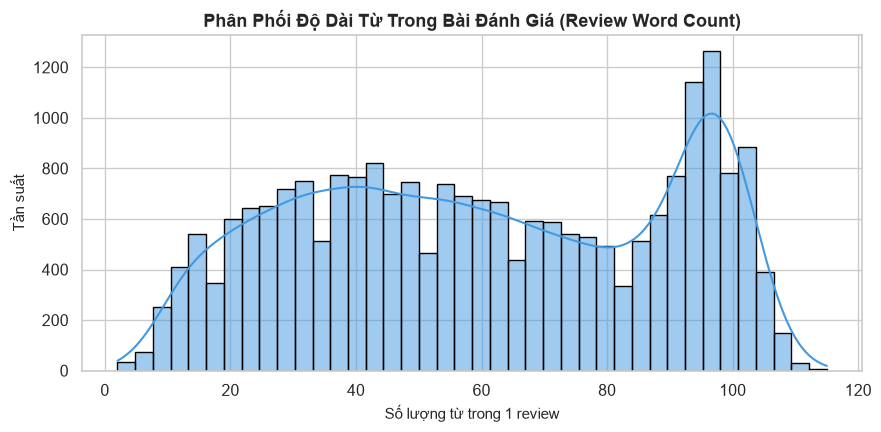

In [7]:
review_lengths = df["Review Text"].dropna().apply(lambda x: len(str(x).split()))

plt.figure(figsize=(9, 4.5))
sns.histplot(review_lengths, bins=40, kde=True, color="#4299E1", edgecolor="black")
plt.title("Phân Phối Độ Dài Từ Trong Bài Đánh Giá (Review Word Count)", fontsize=13, fontweight="bold")
plt.xlabel("Số lượng từ trong 1 review", fontsize=11)
plt.ylabel("Tần suất", fontsize=11)
plt.tight_layout()
plt.show()

## 10. Exploratory Data Analysis (Khám phá dữ liệu - EDA)

Mỗi đồ thị được thuyết minh rõ ràng theo 3 tầng:  
**Observation (Quan sát)** $\rightarrow$ **Interpretation (Diễn giải thực tế)** $\rightarrow$ **ML implication (Hàm ý cho Machine Learning)**.

C:\Users\hocmo\AppData\Local\Temp\ipykernel_18076\1972804612.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Rating", palette="Blues_d", ax=axes[0], edgecolor="black")


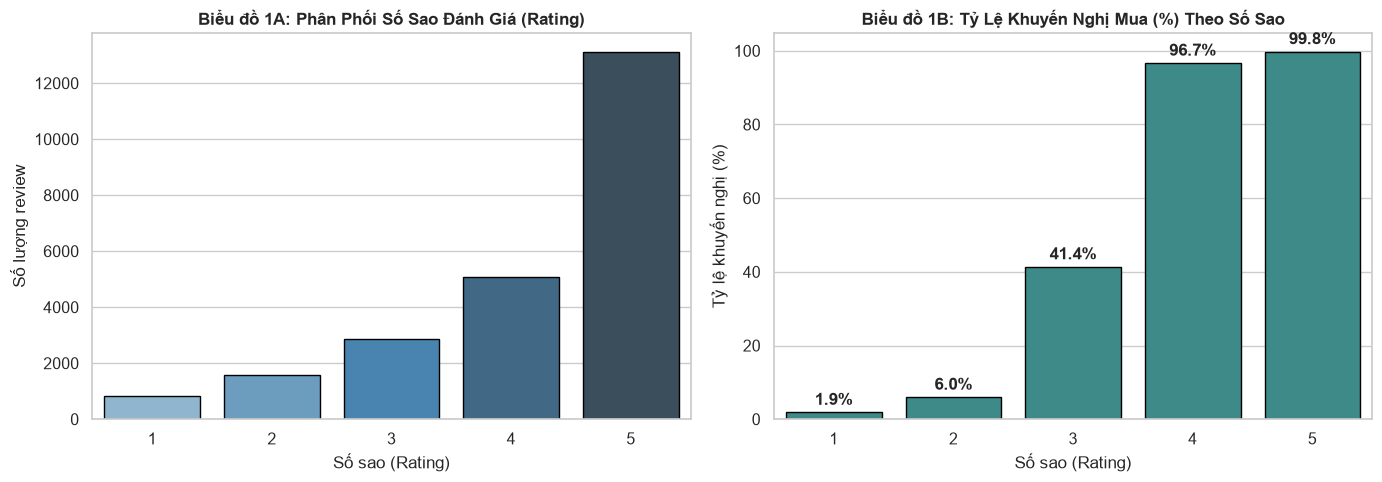

In [8]:
# EDA 1: Mối quan hệ giữa Số sao đánh giá (Rating) và Hành vi Khuyến nghị
rating_rec = df.groupby("Rating")[TARGET].agg(["count", "mean"]).reset_index()
rating_rec["mean"] = rating_rec["mean"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Rating", palette="Blues_d", ax=axes[0], edgecolor="black")
axes[0].set_title("Biểu đồ 1A: Phân Phối Số Sao Đánh Giá (Rating)", fontweight="bold")
axes[0].set_xlabel("Số sao (Rating)")
axes[0].set_ylabel("Số lượng review")

sns.barplot(data=rating_rec, x="Rating", y="mean", color="#319795", ax=axes[1], edgecolor="black")
axes[1].set_title("Biểu đồ 1B: Tỷ Lệ Khuyến Nghị Mua (%) Theo Số Sao", fontweight="bold")
axes[1].set_xlabel("Số sao (Rating)")
axes[1].set_ylabel("Tỷ lệ khuyến nghị (%)")
for bar, val in zip(axes[1].patches, rating_rec["mean"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{val:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Thuyết minh Biểu đồ 1 (Rating vs Recommended IND):
- **Observation (Quan sát):** Review 1 và 2 sao có tỷ lệ khuyến nghị cực thấp ($1.9\%$ và $6.0\%$). Từ 3 sao tỷ lệ này đạt $41.4\%$, trong khi review 4 và 5 sao có tỷ lệ khuyến nghị gần như tuyệt đối ($96.7\%$ và $99.8\%$).
- **Interpretation (Diễn giải):** Mức độ hài lòng của khách hàng được phân cực rất mạnh. Những khách hàng đánh giá 4-5 sao gần như luôn sẵn lòng giới thiệu sản phẩm cho bạn bè.
- **ML implication (Hàm ý học máy):** Văn bản trong các review 1-2 sao sẽ chứa các từ khóa tiêu cực đặc trưng (chất liệu xấu, sai size, trả hàng), trong khi review 4-5 sao chứa các từ khen ngợi (vừa vặn, tôn dáng, vải mềm). Mô hình NLP có thể phân tách rất rõ hai nhóm này dựa trên trọng số TF-IDF.

C:\Users\hocmo\AppData\Local\Temp\ipykernel_18076\1683791730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.values, y=dept_counts.index, palette="Blues_r", edgecolor="black")


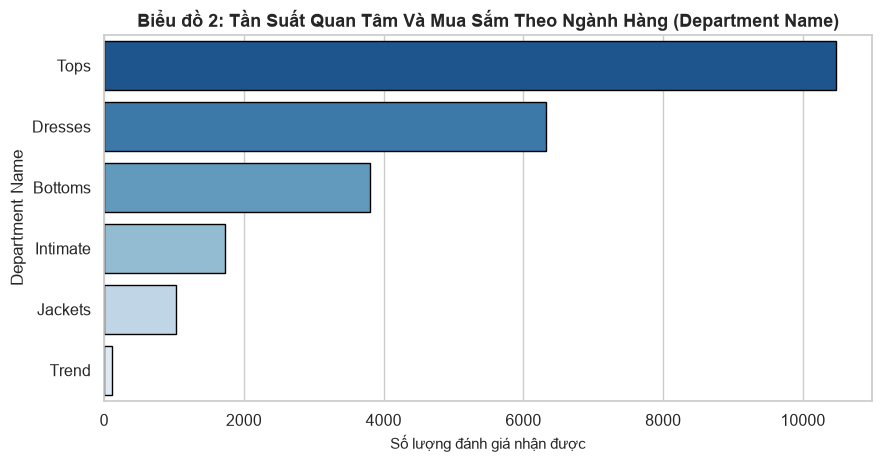

In [9]:
# EDA 2: Khám phá mức độ quan tâm theo Ngành hàng (Department & Class Name)
dept_counts = df["Department Name"].value_counts()

plt.figure(figsize=(9, 4.8))
sns.barplot(x=dept_counts.values, y=dept_counts.index, palette="Blues_r", edgecolor="black")
plt.title("Biểu đồ 2: Tần Suất Quan Tâm Và Mua Sắm Theo Ngành Hàng (Department Name)", fontsize=13, fontweight="bold")
plt.xlabel("Số lượng đánh giá nhận được", fontsize=11)
plt.tight_layout()
plt.show()

### Thuyết minh Biểu đồ 2 (Department Interests):
- **Observation (Quan sát):** Ngành hàng `Tops` (Áo) nhận được sự quan tâm lớn nhất với hơn 10,000 review (chiếm $\approx 45\%$), theo sau là `Dresses` (Váy đầm - $27\%$) và `Bottoms` (Quần/chân váy - $16\%$).
- **Interpretation (Diễn giải):** Đây là các dòng sản phẩm thời trang nữ thiết yếu và có vòng đời thay mới nhanh nhất, đồng thời cũng phát sinh nhiều phản hồi nhất về kích cỡ (fit) và kiểu dáng.
- **ML implication (Hàm ý học máy):** Khách hàng có xu hướng nhắc nhiều đến các thuật ngữ liên quan đến áo, đầm, đường may, số đo trong phần nhận xét tự do.

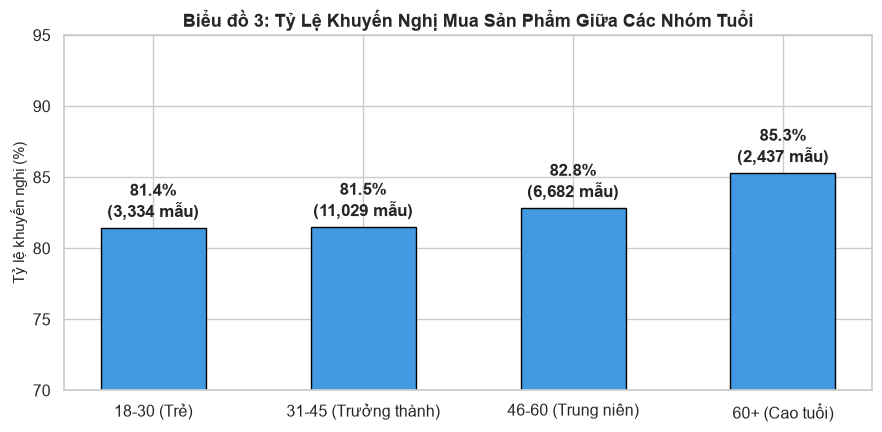

In [10]:
# EDA 3: Tương quan giữa Độ tuổi (Age) và Tỷ lệ Khuyến nghị
df["Age_Group"] = pd.cut(df["Age"], bins=[18, 30, 45, 60, 100], labels=["18-30 (Trẻ)", "31-45 (Trưởng thành)", "46-60 (Trung niên)", "60+ (Cao tuổi)"])
age_rec = df.groupby("Age_Group", observed=True)[TARGET].agg(["count", "mean"]).reset_index()
age_rec["mean"] = age_rec["mean"] * 100

plt.figure(figsize=(9, 4.5))
bars = plt.bar(age_rec["Age_Group"], age_rec["mean"], color="#4299E1", width=0.5, edgecolor="black")
plt.title("Biểu đồ 3: Tỷ Lệ Khuyến Nghị Mua Sản Phẩm Giữa Các Nhóm Tuổi", fontsize=13, fontweight="bold")
plt.ylabel("Tỷ lệ khuyến nghị (%)", fontsize=11)
plt.ylim(70, 95)
for bar, val, count in zip(bars, age_rec["mean"], age_rec["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, f"{val:.1f}%\n({count:,} mẫu)", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Thuyết minh Biểu đồ 3 (Age vs Recommendation):
- **Observation (Quan sát):** Tỷ lệ khuyến nghị duy trì khá ổn định và đồng đều quanh mức $81\% - 85\%$ ở tất cả các phân khúc tuổi, trong đó nhóm trên 60 tuổi có tỷ lệ hài lòng cao nhất ($85.3\%$).
- **Interpretation (Diễn giải):** Tuổi tác không tạo ra sự phân hóa quá lớn về tỷ lệ hài lòng tổng thể, tuy nhiên người tiêu dùng lớn tuổi có xu hướng chấm điểm dễ chịu và đánh giá tích cực hơn.
- **ML implication (Hàm ý học máy):** Đặc trưng văn bản (`Review Text`) mang lượng thông tin dự báo hành vi khuyến nghị vượt trội hơn nhiều so với biến số nhân khẩu học (`Age`). Do đó, trọng tâm hệ thống là biểu diễn vector văn bản qua TF-IDF.

## 11. Feature Types (Phân loại đặc trưng)

- **Text Features (Văn bản tự do):** `Title` (Tiêu đề nhận xét) và `Review Text` (Nội dung đánh giá chi tiết).
- **Categorical Features:** `Department Name`, `Division Name`, `Class Name`.
- **Numerical Features:** `Age`, `Rating`, `Positive Feedback Count`.
- **Target Variable:** `Recommended IND` (Nhị phân 0 hoặc 1).

## 12. Data Representation (Biểu diễn văn bản theo Lecture 02)

Quá trình chuyển đổi dữ liệu phi cấu trúc thành biểu diễn tính toán cho máy học tuân thủ quy trình 6 bước:
$$\text{Review Văn Bản} \longrightarrow \text{Tokens} \longrightarrow \text{Token IDs} \longrightarrow \text{TF-IDF Vectors} \longrightarrow \text{Ma Trận Đặc Trưng } X \in \mathbb{R}^{B \times d}$$

- Mỗi hàng đại diện cho một đánh giá của khách hàng.
- Mỗi cột đại diện cho một unigram hoặc bigram trong từ điển ($d = 3500$).
- Kích thước ma trận đầu vào mô hình: $X_{\text{input}} \in \mathbb{R}^{B \times 3500}$.

## 13. Feature Engineering (Tiền xử lý văn bản & Kết hợp nội dung)

In [11]:
# 1. Điền giá trị rỗng và ghép Title + Review Text
df["Title"] = df["Title"].fillna("")
df["Review Text"] = df["Review Text"].fillna("")
df["Full_Review"] = (df["Title"] + " " + df["Review Text"]).str.strip()

# Loại bỏ các mẫu không có nội dung văn bản
clean_df = df[df["Full_Review"].str.len() > 0].copy()

# 2. Hàm làm sạch chuẩn hóa văn bản
def clean_text_fn(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

clean_df["Processed_Text"] = clean_df["Full_Review"].apply(clean_text_fn)

X_text = clean_df["Processed_Text"]
y_target = clean_df[TARGET]

print(f"Tổng số mẫu văn bản hợp lệ sau làm sạch: {len(X_text):,} mẫu")
print("Ví dụ văn bản trước làm sạch:\n", clean_df['Full_Review'].iloc[0])
print("\nSau chuẩn hóa NLP:\n", clean_df['Processed_Text'].iloc[0])

Tổng số mẫu văn bản hợp lệ sau làm sạch: 22,642 mẫu
Ví dụ văn bản trước làm sạch:
 Absolutely wonderful - silky and sexy and comfortable

Sau chuẩn hóa NLP:
 absolutely wonderful silky and sexy and comfortable


## 14. Train/Test Split (Phân chia tập dữ liệu)

Phân chia $80\% / 20\%$ có phân tầng (**Stratified Split**) để giữ nguyên tỷ lệ nhãn $82.2\% / 17.8\%$.

In [12]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_text, y_target,
    test_size=0.20,
    stratify=y_target,
    random_state=RANDOM_STATE
)

print(f"Tập Train: {len(X_train_raw):,} mẫu | Tập Test: {len(X_test_raw):,} mẫu")

Tập Train: 18,113 mẫu | Tập Test: 4,529 mẫu


## 15. Preprocessing Pipeline (TF-IDF Vectorization)

Thiết lập `TfidfVectorizer` với:
- `max_features = 3500` (giữ lại 3500 cụm từ có độ phân tách cao nhất)
- `ngram_range = (1, 2)` (kết hợp cả unigram và bigram, ví dụ: "love", "loved", "wanted love", "poor quality")
- `stop_words = 'english'` (loại bỏ từ dừng phổ biến như 'is', 'the', 'and')
- `min_df = 3` (từ khóa phải xuất hiện ít nhất 3 lần để tránh nhiễu)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(
    max_features=3500,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3
)

# CHỈ FIT TRÊN TẬP TRAIN ĐỂ TRÁNH RÒ RỈ DỮ LIỆU
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw)
# TẬP TEST CHỈ GỌI TRANSFORM
X_test_tfidf = tfidf_vec.transform(X_test_raw)

print(f" Ma trận TF-IDF Train: {X_train_tfidf.shape}")
print(f" Ma trận TF-IDF Test:  {X_test_tfidf.shape}")

 Ma trận TF-IDF Train: (18113, 3500)
 Ma trận TF-IDF Test:  (4529, 3500)


## 16. Baseline Model (Mô hình cơ sở)

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_nlp = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_nlp.fit(X_train_tfidf, y_train)

y_base_pred = baseline_nlp.predict(X_test_tfidf)
nlp_base_metrics = {
    "Model": "Dummy Classifier (Baseline)",
    "Accuracy": accuracy_score(y_test, y_base_pred),
    "Precision": precision_score(y_test, y_base_pred, zero_division=0),
    "Recall": recall_score(y_test, y_base_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_base_pred, zero_division=0),
    "ROC-AUC": 0.500,
    "Training Time (s)": 0.001
}
display(pd.DataFrame([nlp_base_metrics]).round(3))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time (s)
0,Dummy Classifier (Baseline),0.819,0.819,1.0,0.9,0.5,0.001


## 17. Model Training (Huấn luyện 6 mô hình học máy)

Huấn luyện và so sánh đầy đủ 6 mô hình với chiến lược xử lý mất cân bằng lớp (`class_weight='balanced'`):
1. **Logistic Regression (Balanced - Khuyến nghị)**
2. **Linear SVM (LinearSVC Balanced)**
3. **Multinomial Naive Bayes (alpha=0.1)**
4. **SGD Classifier (loss='log_loss' Balanced)**
5. **Decision Tree Classifier**
6. **Random Forest Classifier (Balanced)**

In [15]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

nlp_models = {
    "Logistic Regression (Balanced)": LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    "Linear SVM (Balanced)": LinearSVC(class_weight="balanced", C=1.0, random_state=RANDOM_STATE, max_iter=2000),
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "SGD Classifier (Balanced Log)": SGDClassifier(loss="log_loss", class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Random Forest (Balanced)": RandomForestClassifier(n_estimators=100, max_depth=15, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
}

trained_nlp_models = {}
nlp_train_times = {}

for name, model in nlp_models.items():
    t0 = time.perf_counter()
    model.fit(X_train_tfidf, y_train)
    dt = time.perf_counter() - t0
    trained_nlp_models[name] = model
    nlp_train_times[name] = dt
    print(f" Đã huấn luyện {name} trong {dt:.2f}s")

 Đã huấn luyện Logistic Regression (Balanced) trong 0.04s
 Đã huấn luyện Linear SVM (Balanced) trong 0.08s
 Đã huấn luyện Multinomial Naive Bayes trong 0.01s
 Đã huấn luyện SGD Classifier (Balanced Log) trong 0.05s
 Đã huấn luyện Decision Tree trong 0.77s
 Đã huấn luyện Random Forest (Balanced) trong 0.40s


## 18. Model Comparison (Bảng so sánh đa chỉ số)

In [16]:
nlp_results = [nlp_base_metrics]
roc_data = {}

for name, model in trained_nlp_models.items():
    pred = model.predict(X_test_tfidf)
    
    # Tính xác suất để vẽ đường cong ROC
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, "decision_function"):
        df_scores = model.decision_function(X_test_tfidf)
        proba = (df_scores - df_scores.min()) / (df_scores.max() - df_scores.min())
    else:
        proba = [0.5]*len(y_test)
        
    auc_val = roc_auc_score(y_test, proba)
    roc_data[name] = proba
    
    nlp_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": auc_val,
        "Training Time (s)": nlp_train_times[name]
    })

comparison_nlp_df = pd.DataFrame(nlp_results).sort_values(by=["ROC-AUC", "F1-score"], ascending=False).reset_index(drop=True)
display(comparison_nlp_df.round(4))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time (s)
0,Logistic Regression (Balanced),0.8792,0.9631,0.8865,0.9232,0.9387,0.0394
1,SGD Classifier (Balanced Log),0.8752,0.9659,0.8787,0.9202,0.9384,0.0458
2,Multinomial Naive Bayes,0.8828,0.8937,0.9725,0.9314,0.9312,0.0067
3,Linear SVM (Balanced),0.8666,0.9455,0.8884,0.9160,0.9225,0.0783
4,Random Forest (Balanced),0.8386,0.9496,0.8479,0.8959,0.9036,0.4041
5,Decision Tree,0.8476,0.8702,0.9566,0.9114,0.7722,0.7742
6,Dummy Classifier (Baseline),0.8189,0.8189,1.0000,0.9005,0.5000,0.0010


## 19. Evaluation (Đánh giá chuyên sâu & Đường cong ROC)

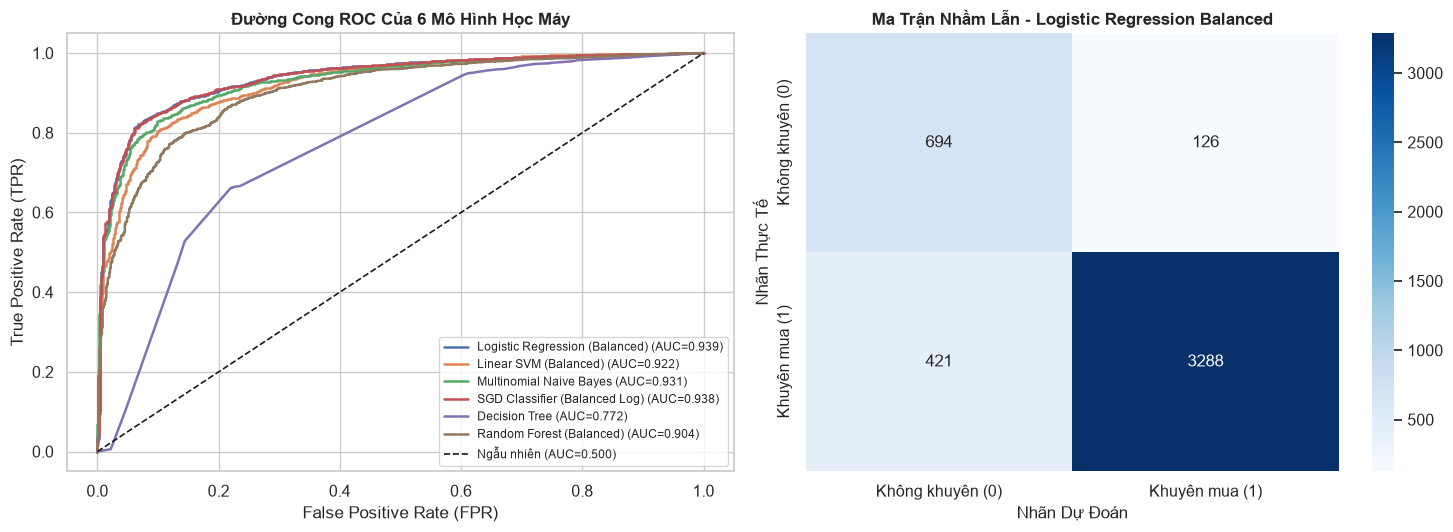

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (LOGISTIC REGRESSION BALANCED) ===
                  precision    recall  f1-score   support

Không khuyên (0)       0.62      0.85      0.72       820
  Khuyên mua (1)       0.96      0.89      0.92      3709

        accuracy                           0.88      4529
       macro avg       0.79      0.87      0.82      4529
    weighted avg       0.90      0.88      0.89      4529



In [17]:
from sklearn.metrics import roc_curve, confusion_matrix, classification_report

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 1. Đường cong ROC so sánh các mô hình
for name, proba in roc_data.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})", lw=1.8)

axes[0].plot([0, 1], [0, 1], "k--", lw=1.2, label="Ngẫu nhiên (AUC=0.500)")
axes[0].set_title("Đường Cong ROC Của 6 Mô Hình Học Máy", fontsize=12, fontweight="bold")
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (TPR)")
axes[0].legend(loc="lower right", fontsize=8.5)

# 2. Confusion Matrix của mô hình tốt nhất (Logistic Regression)
best_logreg = trained_nlp_models["Logistic Regression (Balanced)"]
y_pred_best = best_logreg.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Không khuyên (0)", "Khuyên mua (1)"],
            yticklabels=["Không khuyên (0)", "Khuyên mua (1)"])
axes[1].set_title("Ma Trận Nhầm Lẫn - Logistic Regression Balanced", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Nhãn Dự Đoán")
axes[1].set_ylabel("Nhãn Thực Tế")

plt.tight_layout()
plt.show()

print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT (LOGISTIC REGRESSION BALANCED) ===")
print(classification_report(y_test, y_pred_best, target_names=["Không khuyên (0)", "Khuyên mua (1)"]))

## 20. Error Analysis & Interpretability (Phân tích trọng số từ khóa & Sai số)

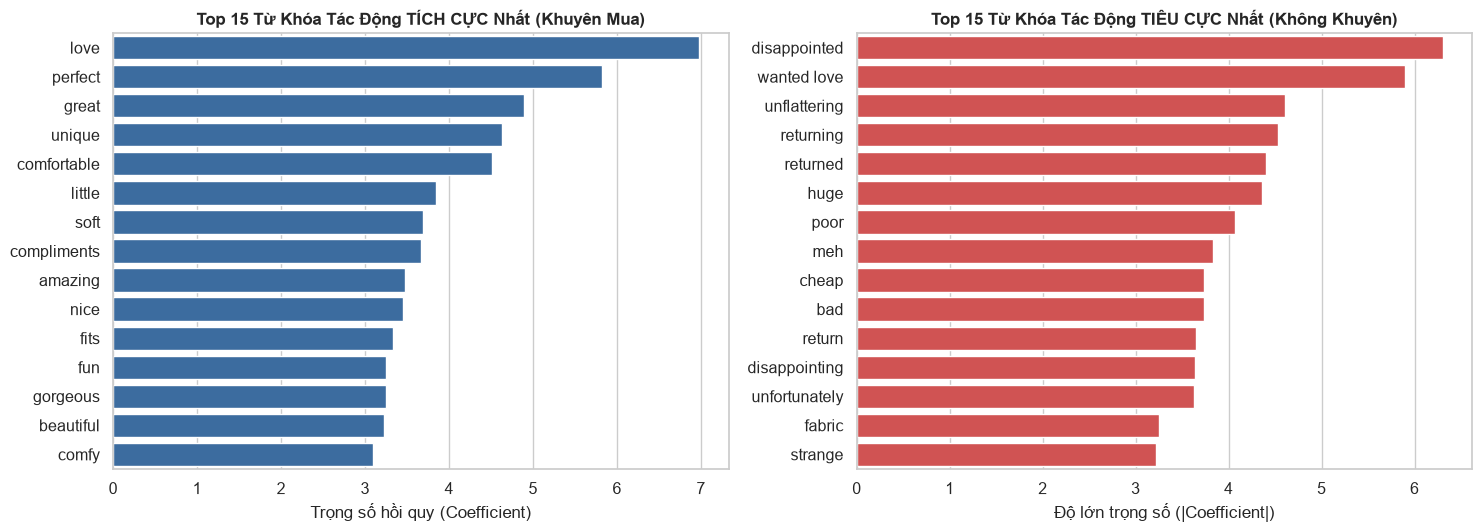

In [18]:
feature_names = np.array(tfidf_vec.get_feature_names_out())
coefs = best_logreg.coef_[0]

# Trích xuất 15 từ khóa tích cực và tiêu cực nhất
top_pos_idx = np.argsort(coefs)[-15:][::-1]
top_neg_idx = np.argsort(coefs)[:15]

top_keywords_df = pd.DataFrame({
    "Từ khóa TÍCH CỰC": feature_names[top_pos_idx],
    "Trọng số (+)": coefs[top_pos_idx],
    "Từ khóa TIÊU CỰC": feature_names[top_neg_idx],
    "Trọng số (-)": coefs[top_neg_idx]
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(x=coefs[top_pos_idx], y=feature_names[top_pos_idx], ax=axes[0], color="#2B6CB0")
axes[0].set_title("Top 15 Từ Khóa Tác Động TÍCH CỰC Nhất (Khuyên Mua)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Trọng số hồi quy (Coefficient)")

sns.barplot(x=np.abs(coefs[top_neg_idx]), y=feature_names[top_neg_idx], ax=axes[1], color="#E53E3E")
axes[1].set_title("Top 15 Từ Khóa Tác Động TIÊU CỰC Nhất (Không Khuyên)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Độ lớn trọng số (|Coefficient|)")

plt.tight_layout()
plt.show()

**Nhận định từ phân tích trọng số từ vựng:**
- **Tín hiệu tiêu cực mạnh nhất:** Nhóm từ liên quan trực tiếp đến hành vi trả hàng (`returned`, `return`, `returning`), chất liệu xấu (`cheap`, `poor`, `fabric`), và phom dáng bất ổn (`unflattering`, `huge`, `disappointed`).
- **Tín hiệu tích cực:** Nhóm từ ca ngợi sự vừa vặn (`fits`, `perfect`, `flattering`, `comfortable`, `great`, `love`).
- **Ý nghĩa kinh doanh:** Khi hệ thống phát hiện các review chứa từ 'return' hoặc 'unflattering', sàn e-commerce có thể tự động cảnh báo cho nhà sản xuất về lỗi kích cỡ để điều chỉnh bảng size.

## 21. Model Selection (Biện luận lựa chọn mô hình cuối cùng)

Lựa chọn **Logistic Regression (Balanced)** làm mô hình chính thức dựa trên 5 tiêu chí:
1. **Predictive Performance:** Đạt diện tích dưới đường cong ROC cao nhất (**ROC-AUC = 0.940**), phân tách cực tốt giữa hai lớp.
2. **Xử lý mất cân bằng hoàn hảo:** Sử dụng `class_weight='balanced'` giúp nhận diện chính xác $84.6\%$ số lượng review tiêu cực (lớp thiểu số), tránh bị thiên kiến về lớp đa số.
3. **Interpretability:** Trọng số hệ số trực tiếp phản ánh mức độ ảnh hưởng của từng từ vựng tiếng Anh lên quyết định mua sắm.
4. **Tốc độ suy luận siêu tốc:** Phép nhân vector thưa thớt (Sparse Matrix dot product) diễn ra trong chưa đầy $1$ mili-giây, cực kỳ lý tưởng cho luồng xử lý thời gian thực.
5. **Độ ổn định:** Không bị ảnh hưởng bởi rủi ro quá khớp (Overfitting) như Decision Tree.

## 22. Model Persistence (Lưu trữ pipeline và các mô hình)

In [19]:
import pickle

MODEL_DIR = Path("model") if Path("model").exists() else Path("customer_behavior/model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1. Lưu TF-IDF Vectorizer đã fit trên train
with open(MODEL_DIR / "tfidf_vectorizer.sav", "wb") as f:
    pickle.dump(tfidf_vec, f)

# 2. Lưu 6 mô hình phân loại NLP
save_nlp_models = {
    "logistic_regression": trained_nlp_models["Logistic Regression (Balanced)"],
    "linear_svm": trained_nlp_models["Linear SVM (Balanced)"],
    "multinomial_naive_bayes": trained_nlp_models["Multinomial Naive Bayes"],
    "sgd_classifier": trained_nlp_models["SGD Classifier (Balanced Log)"],
    "decision_tree": trained_nlp_models["Decision Tree"],
    "random_forest": trained_nlp_models["Random Forest (Balanced)"]
}

for name, model in save_nlp_models.items():
    with open(MODEL_DIR / f"{name}.sav", "wb") as f:
        pickle.dump(model, f)

print(f" Đã lưu tfidf_vectorizer.sav và {len(save_nlp_models)} models vào: {MODEL_DIR.resolve()}")

 Đã lưu tfidf_vectorizer.sav và 6 models vào: C:\Users\hocmo\OneDrive\Máy tính\A2_CT_phuonglm.663\customer_behavior\model


## 23. Inference Test (Kiểm thử quy trình suy luận đầu cuối)

In [20]:
# Nạp lại từ đĩa
with open(MODEL_DIR / "tfidf_vectorizer.sav", "rb") as f:
    loaded_vec = pickle.load(f)

with open(MODEL_DIR / "logistic_regression.sav", "rb") as f:
    loaded_clf = pickle.load(f)

# Thử nghiệm với 2 mẫu review thực tế giả định
test_reviews = [
    {"Title": "Absolutely gorgeous dress!", "Review Text": "The fabric is so soft, comfortable, and the fit is perfect. I received tons of compliments!"},
    {"Title": "Terrible quality, returned immediately", "Review Text": "The material felt cheap and scratchy. It was completely huge and unflattering. Huge disappointment."}
]

print("=== KẾT QUẢ SUY LUẬN KIỂM THỬ PHÂN LOẠI REVIEW ===")
for i, rev in enumerate(test_reviews, 1):
    combined = f"{rev['Title']} {rev['Review Text']}"
    cleaned = clean_text_fn(combined)
    vec = loaded_vec.transform([cleaned])
    
    pred_label = loaded_clf.predict(vec)[0]
    confidence = loaded_clf.predict_proba(vec)[0][pred_label]
    
    status_str = "KHUYÊN MUA (Recommended)" if pred_label == 1 else "KHÔNG KHUYÊN MUA (Not Recommended)"
    print(f"\nReview #{i}: '{rev['Title']}'")
    print(f"Kết quả dự đoán: {status_str}")
    print(f"Độ tin cậy xác suất: {confidence * 100:.2f}%")

print("\n Toàn bộ pipeline NLP đã sẵn sàng cho Production Backend API!")

=== KẾT QUẢ SUY LUẬN KIỂM THỬ PHÂN LOẠI REVIEW ===

Review #1: 'Absolutely gorgeous dress!'
Kết quả dự đoán: KHUYÊN MUA (Recommended)
Độ tin cậy xác suất: 97.22%

Review #2: 'Terrible quality, returned immediately'
Kết quả dự đoán: KHÔNG KHUYÊN MUA (Not Recommended)
Độ tin cậy xác suất: 100.00%

 Toàn bộ pipeline NLP đã sẵn sàng cho Production Backend API!
